Cassava classification experiment 8

Stage-wise fine-tuning from the `ex5` ResNet18 baseline.


1. Library and device setup


In [9]:
import copy
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from collections import Counter

from sklearn.model_selection import train_test_split


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)


In [10]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


2. Class count and disease name


In [11]:
COMPETITION_DATA_DIR = Path("/kaggle/input/competitions/cassava-leaf-disease-classification")
WEIGHTS_PATH = Path("/kaggle/input/datasets/sealzhao/resnet18-f37072fd-pth/resnet18-f37072fd.pth")  # Update this manually to match your attached Kaggle input
TRAIN_CSV_PATH = COMPETITION_DATA_DIR / "train.csv"
LABEL_MAP_PATH = COMPETITION_DATA_DIR / "label_num_to_disease_map.json"
TRAIN_IMAGE_DIR = COMPETITION_DATA_DIR / "train_images"
TEST_CSV_PATH = COMPETITION_DATA_DIR / "sample_submission.csv"
TEST_IMAGE_DIR = COMPETITION_DATA_DIR / "test_images"

print(f"Competition data directory: {COMPETITION_DATA_DIR}")
print(f"Offline ResNet18 checkpoint: {WEIGHTS_PATH}")

if not WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Offline checkpoint not found: {WEIGHTS_PATH}. Update WEIGHTS_PATH to the exact location of 'resnet18-f37072fd.pth' in your attached Kaggle input."
    )

with open(LABEL_MAP_PATH, "r") as f:
    label_num_to_disease_map = json.load(f)

train_df = pd.read_csv(TRAIN_CSV_PATH)
train_counts = Counter(train_df["label"])

print("Training set class counts:\n")
for class_idx, count in sorted(train_counts.items()):
    disease_name = label_num_to_disease_map[str(class_idx)]
    print(f"{disease_name}: {count}")


Competition data directory: /kaggle/input/competitions/cassava-leaf-disease-classification
Offline ResNet18 checkpoint: /kaggle/input/datasets/sealzhao/resnet18-f37072fd-pth/resnet18-f37072fd.pth
Training set class counts:

Cassava Bacterial Blight (CBB): 1087
Cassava Brown Streak Disease (CBSD): 2189
Cassava Green Mottle (CGM): 2386
Cassava Mosaic Disease (CMD): 13158
Healthy: 2577


3. Train and split validation distribution


In [12]:
train_df_split, valid_df_split = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42,
)

train_counts = Counter(train_df_split["label"])
valid_counts = Counter(valid_df_split["label"])

print("Training set class counts:\n")
for class_idx, count in sorted(train_counts.items()):
    print(f"{label_num_to_disease_map[str(class_idx)]}: {count}")

print("\nValidation set class counts:\n")
for class_idx, count in sorted(valid_counts.items()):
    print(f"{label_num_to_disease_map[str(class_idx)]}: {count}")


Training set class counts:

Cassava Bacterial Blight (CBB): 870
Cassava Brown Streak Disease (CBSD): 1751
Cassava Green Mottle (CGM): 1909
Cassava Mosaic Disease (CMD): 10526
Healthy: 2061

Validation set class counts:

Cassava Bacterial Blight (CBB): 217
Cassava Brown Streak Disease (CBSD): 438
Cassava Green Mottle (CGM): 477
Cassava Mosaic Disease (CMD): 2632
Healthy: 516


4. ResNet18 setup and fine-tuning plan


This notebook keeps the `ex5` data pipeline, loss, and offline checkpoint loading, then improves the training schedule by gradually unfreezing the backbone.

Fine-tuning stages:
- `head_only`: train only the classification head to adapt quickly to cassava classes.
- `layer4`: unfreeze the last residual block with a smaller learning rate.
- `layer3_layer4`: unfreeze one more block and continue with even smaller backbone learning rates.

This makes the update steps safer than unfreezing the full network immediately.


In [13]:
def build_model(num_classes=5, weights_path=WEIGHTS_PATH):
    if not weights_path.exists():
        raise FileNotFoundError(f"Offline checkpoint not found: {weights_path}")

    model = models.resnet18(weights=None)
    state_dict = torch.load(weights_path, map_location="cpu")
    model.load_state_dict(state_dict)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def count_trainable_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


In [14]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, reduction="mean", ignore_index=-100):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction
        self.ignore_index = ignore_index
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction="none", ignore_index=ignore_index)

    def forward(self, logits, target):
        logpt = -self.ce(logits, target)
        pt = logpt.exp()
        focal_term = (1 - pt) ** self.gamma
        loss = -focal_term * logpt

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


def set_trainable_layers(model, trainable_prefixes):
    trainable_prefixes = tuple(trainable_prefixes)
    for name, param in model.named_parameters():
        param.requires_grad = any(name.startswith(prefix) for prefix in trainable_prefixes)


def freeze_batchnorm_stats(model, trainable_prefixes):
    backbone_prefixes = tuple(prefix for prefix in trainable_prefixes if prefix != "fc")
    for name, module in model.named_modules():
        if isinstance(module, nn.BatchNorm2d):
            if backbone_prefixes and any(name.startswith(prefix) for prefix in backbone_prefixes):
                module.train()
            else:
                module.eval()


def build_stage_optimizer(model, lr_map, weight_decay=1e-4):
    param_groups = []
    seen_params = set()

    for prefix, lr in lr_map.items():
        params = [
            param
            for name, param in model.named_parameters()
            if param.requires_grad and name.startswith(prefix)
        ]
        if params:
            param_groups.append({"params": params, "lr": lr})
            seen_params.update(id(param) for param in params)

    remaining_params = [
        param
        for param in model.parameters()
        if param.requires_grad and id(param) not in seen_params
    ]
    if remaining_params:
        param_groups.append({"params": remaining_params, "lr": min(lr_map.values())})

    return torch.optim.AdamW(param_groups, weight_decay=weight_decay)


In [15]:
model = build_model().to(device)
criterion = FocalLoss(gamma=1.0)

fine_tune_stages = [
    {
        "name": "head_only",
        "epochs": 2,
        "trainable_layers": ["fc"],
        "lr_map": {"fc": 3e-4},
    },
    {
        "name": "layer4",
        "epochs": 3,
        "trainable_layers": ["layer4", "fc"],
        "lr_map": {"layer4": 1e-4, "fc": 3e-4},
    },
    {
        "name": "layer3_layer4",
        "epochs": 4,
        "trainable_layers": ["layer3", "layer4", "fc"],
        "lr_map": {"layer3": 3e-5, "layer4": 1e-4, "fc": 2e-4},
    },
]

for stage in fine_tune_stages:
    print(stage)


{'name': 'head_only', 'epochs': 2, 'trainable_layers': ['fc'], 'lr_map': {'fc': 0.0003}}
{'name': 'layer4', 'epochs': 3, 'trainable_layers': ['layer4', 'fc'], 'lr_map': {'layer4': 0.0001, 'fc': 0.0003}}
{'name': 'layer3_layer4', 'epochs': 4, 'trainable_layers': ['layer3', 'layer4', 'fc'], 'lr_map': {'layer3': 3e-05, 'layer4': 0.0001, 'fc': 0.0002}}


5. Creating dataset class


In [16]:
class CassavaDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["image_id"]
        label = self.df.iloc[idx]["label"]

        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


6. Train and evaluation transforms


In [17]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


7. Creating train and valid dataset


In [18]:
train_dataset = CassavaDataset(
    df=train_df_split,
    image_dir=TRAIN_IMAGE_DIR,
    transform=train_transform,
)

valid_dataset = CassavaDataset(
    df=valid_df_split,
    image_dir=TRAIN_IMAGE_DIR,
    transform=eval_transform,
)


In [19]:
pin_memory = device.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=pin_memory)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=pin_memory)


8. Training helpers


In [20]:
def train_one_epoch(model, loader, optimizer, criterion, device, trainable_prefixes):
    model.train()
    freeze_batchnorm_stats(model, trainable_prefixes)

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        predictions = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    average_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return average_loss, accuracy


def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    average_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return average_loss, accuracy


9. Stage-wise fine-tuning ResNet18


In [21]:
history = []
best_val_accuracy = 0.0
best_model_state = copy.deepcopy(model.state_dict())
best_stage_name = None
best_global_epoch = 0

global_epoch = 0
total_epochs = sum(stage["epochs"] for stage in fine_tune_stages)

for stage in fine_tune_stages:
    stage_name = stage["name"]
    trainable_layers = stage["trainable_layers"]

    set_trainable_layers(model, trainable_layers)
    optimizer = build_stage_optimizer(model, stage["lr_map"], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
    )

    print(f"\nStarting stage: {stage_name}")
    print(f"Trainable layers: {trainable_layers}")
    print(f"Learning rates: {stage['lr_map']}")
    print(f"Trainable parameters: {count_trainable_parameters(model):,}")

    for stage_epoch in range(1, stage["epochs"] + 1):
        global_epoch += 1

        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            trainable_layers,
        )
        valid_loss, valid_accuracy = evaluate_model(model, valid_loader, criterion, device)
        scheduler.step(valid_accuracy)

        current_lrs = [group["lr"] for group in optimizer.param_groups]
        history.append(
            {
                "stage": stage_name,
                "stage_epoch": stage_epoch,
                "global_epoch": global_epoch,
                "train_loss": train_loss,
                "train_accuracy": train_accuracy,
                "valid_loss": valid_loss,
                "valid_accuracy": valid_accuracy,
                "learning_rates": current_lrs,
            }
        )

        print(f"Epoch [{global_epoch}/{total_epochs}] ({stage_name} - {stage_epoch}/{stage['epochs']})")
        print(f"Training Loss: {train_loss:.4f}")
        print(f"Training Accuracy: {train_accuracy:.2f}%")
        print(f"Validation Loss: {valid_loss:.4f}")
        print(f"Validation Accuracy: {valid_accuracy:.2f}%")
        print(f"Current LRs: {current_lrs}\n")

        if valid_accuracy > best_val_accuracy:
            best_val_accuracy = valid_accuracy
            best_model_state = copy.deepcopy(model.state_dict())
            best_stage_name = stage_name
            best_global_epoch = global_epoch

model.load_state_dict(best_model_state)
torch.save(best_model_state, "best_resnet18_finetuned.pth")

print(f"Best validation accuracy: {best_val_accuracy:.2f}%")
print(f"Best stage: {best_stage_name}")
print(f"Best global epoch: {best_global_epoch}")
print("Saved best_resnet18_finetuned.pth")



Starting stage: head_only
Trainable layers: ['fc']
Learning rates: {'fc': 0.0003}
Trainable parameters: 2,565
Epoch [1/9] (head_only - 1/2)
Training Loss: 0.7069
Training Accuracy: 65.55%
Validation Loss: 0.6144
Validation Accuracy: 69.46%
Current LRs: [0.0003]

Epoch [2/9] (head_only - 2/2)
Training Loss: 0.5700
Training Accuracy: 70.54%
Validation Loss: 0.5641
Validation Accuracy: 70.58%
Current LRs: [0.0003]


Starting stage: layer4
Trainable layers: ['layer4', 'fc']
Learning rates: {'layer4': 0.0001, 'fc': 0.0003}
Trainable parameters: 8,396,293
Epoch [3/9] (layer4 - 1/3)
Training Loss: 0.4905
Training Accuracy: 74.64%
Validation Loss: 0.4224
Validation Accuracy: 78.53%
Current LRs: [0.0001, 0.0003]

Epoch [4/9] (layer4 - 2/3)
Training Loss: 0.2967
Training Accuracy: 84.32%
Validation Loss: 0.4604
Validation Accuracy: 78.60%
Current LRs: [0.0001, 0.0003]

Epoch [5/9] (layer4 - 3/3)
Training Loss: 0.1884
Training Accuracy: 89.67%
Validation Loss: 0.4700
Validation Accuracy: 77.94%


In [22]:
history_df = pd.DataFrame(history)
history_df


,stage,stage_epoch,global_epoch,train_loss,train_accuracy,valid_loss,valid_accuracy,learning_rates
0,head_only,1,1,0.706859,65.554712,0.614444,69.462617,[0.0003]
1,head_only,2,2,0.569956,70.543904,0.564083,70.584112,[0.0003]
2,layer4,1,3,0.490525,74.639248,0.422425,78.528037,"[0.0001, 0.0003]"
3,layer4,2,4,0.296694,84.319682,0.460439,78.598131,"[0.0001, 0.0003]"
4,layer4,3,5,0.188440,89.671087,0.469977,77.943925,"[0.0001, 0.0003]"
5,layer3_layer4,1,6,0.215156,88.029444,0.472533,77.757009,"[3e-05, 0.0001, 0.0002]"
6,layer3_layer4,2,7,0.110333,93.935853,0.537709,78.130841,"[3e-05, 0.0001, 0.0002]"
7,layer3_layer4,3,8,0.074395,95.787813,0.597211,79.018692,"[3e-05, 0.0001, 0.0002]"
8,layer3_layer4,4,9,0.054721,97.032190,0.643707,78.831776,"[3e-05, 0.0001, 0.0002]"


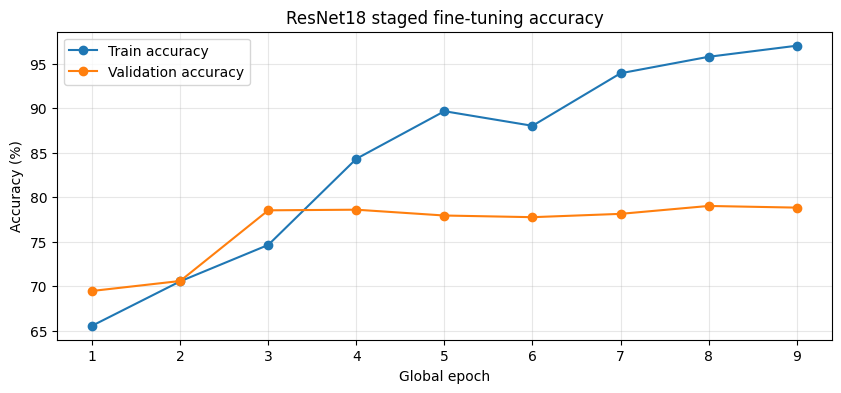

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(history_df["global_epoch"], history_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(history_df["global_epoch"], history_df["valid_accuracy"], marker="o", label="Validation accuracy")
plt.xlabel("Global epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 staged fine-tuning accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [24]:
test_df = pd.read_csv(TEST_CSV_PATH)


class CassavaTestDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["image_id"]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_name


test_dataset = CassavaTestDataset(test_df, TEST_IMAGE_DIR, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=pin_memory)

model.eval()
preds = []
ids = []
with torch.no_grad():
    for images, image_ids in test_loader:
        images = images.to(device)
        outputs = model(images)
        predicted = outputs.argmax(dim=1)
        preds.extend(predicted.cpu().numpy().tolist())
        ids.extend(image_ids)

submission = pd.DataFrame({"image_id": ids, "label": preds})
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")


Saved submission.csv


10. Next fine-tuning ideas

Suggested order after this notebook:
- If `layer3_layer4` improves validation accuracy, try one extra stage that also unfreezes `layer2` with a very small learning rate such as `1e-5`.
- Compare `FocalLoss(gamma=1.0)` against plain `CrossEntropyLoss(label_smoothing=0.1)` once the fine-tuning schedule is stable.
- Keep the staged schedule fixed and then test stronger augmentation, such as `RandomRotation(10)` or `ColorJitter`, one change at a time.
- If GPU memory allows it, compare `256x256` against `320x320` input size after the layer schedule is working well.
